# Training des GBERT-Regressors auf synthetischen LLM-Zwischenstufen

Dieses Notebook trainiert ein kontinuierliches Komplexitäts-Regressionsmodell (`GBERTRegressor`) auf den vom LLM erzeugten synthetischen Zwischenstufen (Stufen `0.0`, `0.25`, `0.50`, `0.75`, `1.0`).

## 1. Datenarchitektur
Jeder Artikel aus `corpus_final_with_steps.json` enthält 5 Sprachstufen:
- **Stufe 0.00:** Leichte Sprache (`ls_text`)
- **Stufe 0.25:** Synthetische Stufe nahe an Leichter Sprache (`intermediate_steps['0.25']`)
- **Stufe 0.50:** Synthetische Einfache Sprache (`intermediate_steps['0.50']`)
- **Stufe 0.75:** Synthetische Stufe nahe an Alltagssprache (`intermediate_steps['0.75']`)
- **Stufe 1.00:** Alltagssprache (`as_text`)


In [1]:
import os
import sys

# Arbeitsverzeichnis auf das Root-Verzeichnis des Repositories setzen
while not os.path.exists(".git"):
    parent = os.path.dirname(os.getcwd())
    if parent == os.getcwd():  # System-Root erreicht, Abbruch
        break
    os.chdir("..")

print("Aktuelles Arbeitsverzeichnis:", os.getcwd())


Aktuelles Arbeitsverzeichnis: /home/fiete/master-thesis


In [2]:
import torch
print("CUDA verfügbar:", torch.cuda.is_available())
print("Device Name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "Keine GPU")

# Set seed for reproducibility
def set_seed(seed=42):
    import random
    import numpy as np
    import torch
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    print(f"Globaler Seed auf {seed} gesetzt.")

set_seed(42)


CUDA verfügbar: True
Device Name: NVIDIA GeForce RTX 4090
Globaler Seed auf 42 gesetzt.


In [3]:
# ==============================================================================
# ZENTRALE KONFIGURATION & PARAMS (Hier anpassen)
# ==============================================================================
CORPUS_WITH_STEPS_PATH = "data/corpus/final_with_steps.json"
LH_WITH_STEPS_PATH = "data/lebenshilfe/lebenshilfe_dataset_with_steps.json"
MODEL_SAVE_PATH = "results/models/gbert_synthetic_regression.pt"
MODEL_NAME = "deepset/gbert-base"

EPOCHS = 15
BATCH_SIZE = 16
MAX_SEQ_LEN = 256
LR = 2e-5


In [4]:
import json
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns
from torch.utils.data import Dataset, DataLoader
from tqdm.notebook import tqdm
from collections import Counter
from scipy.stats import pearsonr, spearmanr
from transformers import BertTokenizerFast, BertModel

# Reproduzierbarkeit
SEED = 42
set_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu"))
print(f"Nutze Device: {device}")


Globaler Seed auf 42 gesetzt.
Nutze Device: cuda


## 2. Dataset-Klasse für synthetische Stufen (mit GBERT Tokenizer)


In [5]:
def load_flattened_samples(json_path):
    if not os.path.exists(json_path):
        raise FileNotFoundError(f"Datei nicht gefunden: {json_path}")
        
    with open(json_path, "r", encoding="utf-8") as f:
        articles = json.load(f)
        
    samples = []
    for art_idx, art in enumerate(articles):
        ls_text = art.get("ls_text", "").strip()
        as_text = art.get("as_text", "").strip()
        steps = art.get("intermediate_steps", {})
        
        if ls_text:
            samples.append({"text": ls_text, "target": 1.0, "article_id": art_idx, "stage": "1.00 (LS)"})
        if as_text:
            samples.append({"text": as_text, "target": 0.0, "article_id": art_idx, "stage": "0.00 (AS)"})
            
        for step_str, step_text in steps.items():
            try:
                target_val = float(step_str)
                if step_text and step_text.strip():
                    samples.append({
                        "text": step_text.strip(),
                        "target": 1.0 - target_val,
                        "article_id": art_idx,
                        "stage": f"{1.0 - target_val:.2f}"
                    })
            except ValueError:
                continue
                
    return samples, articles

raw_samples, raw_articles = load_flattened_samples(CORPUS_WITH_STEPS_PATH)
print(f"Anzahl geladener Artikel: {len(raw_articles)}")
print(f"Anzahl ausgeflachter Text-Samples: {len(raw_samples)}")

# Verteilung der Stufen anzeigen
stage_counts = Counter(s["stage"] for s in raw_samples)
for stage, count in sorted(stage_counts.items()):
    print(f"  Stufe {stage}: {count} Samples")


Anzahl geladener Artikel: 1476
Anzahl ausgeflachter Text-Samples: 7380
  Stufe 0.00 (AS): 1476 Samples
  Stufe 0.25: 1476 Samples
  Stufe 0.50: 1476 Samples
  Stufe 0.75: 1476 Samples
  Stufe 1.00 (LS): 1476 Samples


## 3. PyTorch Dataset & DataLoader

Wir nutzen den Tokenizer von `deepset/gbert-base`.


In [6]:
tokenizer = BertTokenizerFast.from_pretrained(MODEL_NAME)

class SyntheticStepGBERTDataset(Dataset):
    def __init__(self, samples, tokenizer, max_len=MAX_SEQ_LEN):
        self.samples = samples
        self.tokenizer = tokenizer
        self.max_len = max_len
        
    def __len__(self):
        return len(self.samples)
        
    def __getitem__(self, idx):
        item = self.samples[idx]
        text = item["text"]
        target = item["target"]
        
        encoding = self.tokenizer(
            text,
            truncation=True,
            max_length=self.max_len,
            padding="max_length",
            return_tensors="pt"
        )
        
        return {
            "input_ids": encoding["input_ids"].squeeze(0),
            "attention_mask": encoding["attention_mask"].squeeze(0),
            "target": torch.tensor(target, dtype=torch.float32)
        }

# Split auf Artikel-Ebene (80% Train, 20% Val)
unique_art_ids = list(set(s["article_id"] for s in raw_samples))
random.shuffle(unique_art_ids)
split_idx = int(0.8 * len(unique_art_ids))
train_art_ids = set(unique_art_ids[:split_idx])
val_art_ids = set(unique_art_ids[split_idx:])

train_samples = [s for s in raw_samples if s["article_id"] in train_art_ids]
val_samples = [s for s in raw_samples if s["article_id"] in val_art_ids]

print(f"Train-Samples: {len(train_samples)} (aus {len(train_art_ids)} Artikeln)")
print(f"Val-Samples: {len(val_samples)} (aus {len(val_art_ids)} Artikeln)")

train_ds = SyntheticStepGBERTDataset(train_samples, tokenizer, max_len=MAX_SEQ_LEN)
val_ds = SyntheticStepGBERTDataset(val_samples, tokenizer, max_len=MAX_SEQ_LEN)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)


/home/fiete/master-thesis/.venv/lib/python3.12/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Train-Samples: 5900 (aus 1180 Artikeln)
Val-Samples: 1480 (aus 296 Artikeln)


## 4. Modelldefinition (GBERT Regressor)

Wir nutzen ein deutsches BERT-Modell und fügen einen Regressionskopf mit Sigmoid-Aktivierung hinzu, da unser Targetwert $\lambda$ stetig zwischen 0.0 und 1.0 liegt.


In [7]:
class GBERTRegressor(nn.Module):
    def __init__(self, model_name=MODEL_NAME, dropout_rate=0.1):
        super(GBERTRegressor, self).__init__()
        self.gbert = BertModel.from_pretrained(model_name)
        self.dropout = nn.Dropout(dropout_rate)
        self.regressor = nn.Linear(self.gbert.config.hidden_size, 1)
        self.sigmoid = nn.Sigmoid()
        
    def forward(self, input_ids, attention_mask):
        outputs = self.gbert(input_ids=input_ids, attention_mask=attention_mask)
        # Verwende die CLS-Token Repräsentation
        cls_rep = outputs.last_hidden_state[:, 0, :]
        dropped = self.dropout(cls_rep)
        logits = self.regressor(dropped)
        return self.sigmoid(logits)


## 5. Training des Modells

Wir fine-tunen GBERT mit dem AdamW Optimizer und MSE Loss.


In [8]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import torch.optim as optim

model = GBERTRegressor(MODEL_NAME).to(device)
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=0.01)
criterion = nn.MSELoss()

best_val_loss = float("inf")
patience = 4
counter = 0
history = {"train_loss": [], "val_loss": [], "val_mae": []}

for epoch in range(EPOCHS):
    model.train()
    epoch_loss = 0.0
    for batch in tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Train]"):
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        targets = batch["target"].to(device)
        
        optimizer.zero_grad()
        preds = model(input_ids, attention_mask).squeeze(-1)
        loss = criterion(preds, targets)
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()
        
    # Evaluation
    model.eval()
    val_loss = 0.0
    all_preds = []
    all_targets = []
    
    with torch.no_grad():
        for batch in tqdm(val_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Val]"):
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            targets = batch["target"].to(device)
            
            preds = model(input_ids, attention_mask).squeeze(-1)
            loss = criterion(preds, targets)
            val_loss += loss.item()
            
            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(targets.cpu().numpy())
            
    epoch_train_loss = epoch_loss / len(train_loader)
    epoch_val_loss = val_loss / len(val_loader)
    epoch_val_mae = mean_absolute_error(all_targets, all_preds)
    
    history["train_loss"].append(epoch_train_loss)
    history["val_loss"].append(epoch_val_loss)
    history["val_mae"].append(epoch_val_mae)
    
    print(f"Epoch {epoch+1:02d} | Train Loss: {epoch_train_loss:.4f} | Val Loss: {epoch_val_loss:.4f} | Val MAE: {epoch_val_mae:.4f}")
    
    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        os.makedirs(os.path.dirname(MODEL_SAVE_PATH), exist_ok=True)
        torch.save(model.state_dict(), MODEL_SAVE_PATH)
        print(f"  => Modell mit bestem Val Loss ({best_val_loss:.4f}) unter {MODEL_SAVE_PATH} gespeichert.")
        counter = 0
    else:
        counter += 1
        if counter >= patience:
            print("Early Stopping ausgelöst.")
            break


Epoch 1/15 [Train]:   0%|          | 0/369 [00:00<?, ?it/s]

Epoch 1/15 [Val]:   0%|          | 0/93 [00:00<?, ?it/s]

Epoch 01 | Train Loss: 0.0291 | Val Loss: 0.0162 | Val MAE: 0.0797
  => Modell mit bestem Val Loss (0.0162) unter results/models/gbert_synthetic_regression.pt gespeichert.


Epoch 2/15 [Train]:   0%|          | 0/369 [00:00<?, ?it/s]

Epoch 2/15 [Val]:   0%|          | 0/93 [00:00<?, ?it/s]

...

Epoch 7/15 [Val]:   0%|          | 0/93 [00:00<?, ?it/s]

Epoch 07 | Train Loss: 0.0031 | Val Loss: 0.0110 | Val MAE: 0.0593


Epoch 8/15 [Train]:   0%|          | 0/369 [00:00<?, ?it/s]

Epoch 8/15 [Val]:   0%|          | 0/93 [00:00<?, ?it/s]

Epoch 08 | Train Loss: 0.0028 | Val Loss: 0.0114 | Val MAE: 0.0590
Early Stopping ausgelöst.


## 6. Auswertung und Visualisierung des Trainingsverlaufs


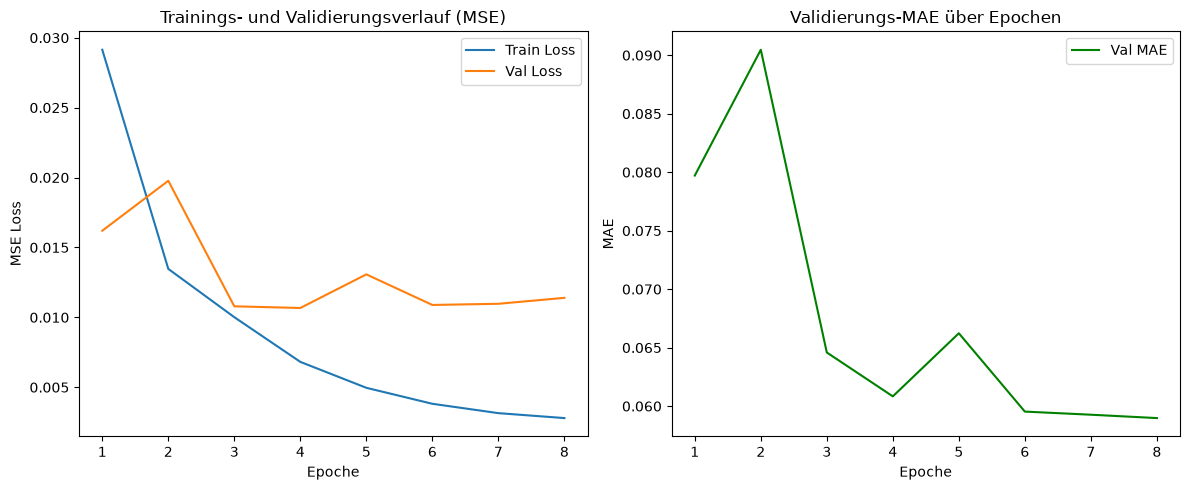

In [9]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(range(1, len(history["train_loss"])+1), history["train_loss"], label="Train Loss")
plt.plot(range(1, len(history["val_loss"])+1), history["val_loss"], label="Val Loss")
plt.xlabel("Epoche")
plt.ylabel("MSE Loss")
plt.title("Trainings- und Validierungsverlauf (MSE)")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(range(1, len(history["val_mae"])+1), history["val_mae"], label="Val MAE", color="green")
plt.xlabel("Epoche")
plt.ylabel("MAE")
plt.title("Validierungs-MAE über Epochen")
plt.legend()
plt.tight_layout()
plt.show()


## 7. Out-of-Domain Evaluation auf Lebenshilfe-Datensatz


In [10]:
# Bestes Modell laden
model.load_state_dict(torch.load(MODEL_SAVE_PATH, map_location=device))
model.eval()

lh_samples, _ = load_flattened_samples(LH_WITH_STEPS_PATH)
print(f"Anzahl geladener Lebenshilfe Samples: {len(lh_samples)}")

lh_ds = SyntheticStepGBERTDataset(lh_samples, tokenizer, max_len=MAX_SEQ_LEN)
lh_loader = DataLoader(lh_ds, batch_size=BATCH_SIZE, shuffle=False)

lh_preds = []
lh_targets = []

with torch.no_grad():
    for batch in tqdm(lh_loader, desc="Lebenshilfe Eval"):
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        targets = batch["target"].to(device)
        
        preds = model(input_ids, attention_mask).squeeze(-1)
        lh_preds.extend(preds.cpu().numpy())
        lh_targets.extend(targets.cpu().numpy())

lh_mse = mean_squared_error(lh_targets, lh_preds)
lh_mae = mean_absolute_error(lh_targets, lh_preds)
p_corr, _ = pearsonr(lh_targets, lh_preds)
s_corr, _ = spearmanr(lh_targets, lh_preds)

print(f"Lebenshilfe MSE: {lh_mse:.4f}")
print(f"Lebenshilfe MAE: {lh_mae:.4f}")
print(f"Pearson Korrelation: {p_corr:.4f}")
print(f"Spearman Korrelation: {s_corr:.4f}")


Anzahl geladener Lebenshilfe Samples: 245


Lebenshilfe Eval:   0%|          | 0/16 [00:00<?, ?it/s]

Lebenshilfe MSE: 0.0323
Lebenshilfe MAE: 0.0931
Pearson Korrelation: 0.8715
Spearman Korrelation: 0.8640
